# Greenness, Parks, and Mental Distress in Washington, DC
### A tract-level data science analysis of environmental exposure and community mental health

## Objective
This project examines whether neighborhood greenness and park access are associated with frequent mental distress across Washington, DC census tracts. The analysis combines satellite-derived NDVI, park polygon data, and CDC PLACES mental health estimates, and extends beyond descriptive spatial analysis by incorporating feature engineering, predictive modeling, and model evaluation.

### Imports and Environmental Setup

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


## Data Sources
This project integrates environmental, public health, socioeconomic, and spatial datasets to examine the relationship between urban greenness and mental distress across census tracts in Washington, DC.

All datasets were aggregated and merged using census tract GEOIDs.

This project integrates:
- CDC PLACES mental distress estimates
- NDVI greenness data from Google Earth Engine
- ACS socioeconomic variables
- DC park polygon spatial data

### CDC PLACES

**Source:**
Centers for Disease Control and Prevention (CDC) PLACES Dataset
https://data.cdc.gov/

**Purpose:** used to measure-tract level mental health outcomes

**Filtering Steps:**
* Washington, DC census tracts
* Measurem = "Frequent mental distress among adults"

**Variables Used:** ```LocationID``` ```Data_Value``` ```Total Population```



### NDVI Greenness Data

**Source:**
Google Earth Engine using Landsat 9 Surface Reflectance imagery
https://earthengine.google.com/

**Purpose:** Used to quantify neighborhood-level environmental greenness.

**Method:**
Normalized Difference Vegetation Index (NDVI) values were calculated using:

```
(image.normalizedDifference(['SR_B5', 'SR_B4']))

```



### American Community Survey (ACS)

**Source:** United States Census Bureau — American Community Survey (ACS) 5-Year Estimates
https://www.census.gov/data/developers/data-sets/acs-5year.html?

**Purpose:** Used to control for socioeconomic confounding factors associated with mental distress.

**Variables:** ```poverty_rate``` ```unemployment_rate``` ```median_income```

**Data Retrival:** Variables were retrieved programmatically using the Census API and merged using census tract GEOIDs

### Park Polygon

**Source:** District of Columbia Open Data Portal https://opendata.dc.gov/datasets/dc-health-planning-neighborhoods/explore?location=38.893596%2C-77.014576%2C11

**Purpose:** Used to quantify park exposure and recreational green space availability.

**Spatial Processing:** Park polygon geometries were intersected with census tract boundaries using GeoPandas.

Several park exposure variables were created:

```park_area_km2``` ```park_share``` ````has_park```

- Spatial area calculations were performed using a projected CRS to ensure accurate area estimation.


## Data Cleaning


### Data Import

In [ ]:
mental = pd.read_csv("PLACES_tract_2025.csv")
ndvi = pd.read_csv("DC_TractMean_NDVI_2023_MaySep_Landsat9.csv")

print(mental.columns.to_list())
print(ndvi.columns.to_list())

['Year', 'StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS', 'LocationName', 'DataSource', 'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type', 'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation', 'TotalPop18plus', 'Geolocation', 'LocationID', 'CategoryID', 'MeasureId', 'DataValueTypeID', 'Short_Question_Text']
['system:index', 'ALAND', 'AWATER', 'COUNTYFP', 'FUNCSTAT', 'GEOID', 'INTPTLAT', 'INTPTLON', 'MTFCC', 'NAME', 'NAMELSAD', 'STATEFP', 'TRACTCE', 'mean', '.geo']


In [38]:
mental.head()

,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,DC,District of Columbia,District of Columbia,11001,11001005602,BRFSS,Health Status,Frequent mental distress among adults,%,...,10.9,15.0,"4,100","3,946",POINT (-77.0554558 38.8988888),11001005602,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
1,2023,DC,District of Columbia,District of Columbia,11001,11001001004,BRFSS,Health Status,Frequent mental distress among adults,%,...,10.1,13.5,"4,480","3,529",POINT (-77.0853886 38.9487665),11001001004,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
2,2023,DC,District of Columbia,District of Columbia,11001,11001000201,BRFSS,Health Status,Frequent mental distress among adults,%,...,28.2,35.2,"4,108","4,079",POINT (-77.0743418 38.9092171),11001000201,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
3,2023,DC,District of Columbia,District of Columbia,11001,11001009302,BRFSS,Health Status,Frequent mental distress among adults,%,...,12.1,15.8,"1,750","1,476",POINT (-76.9907773 38.9251636),11001009302,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
4,2023,DC,District of Columbia,District of Columbia,11001,11001000903,BRFSS,Health Status,Frequent mental distress among adults,%,...,15.0,21.4,"4,202","3,953",POINT (-77.093331 38.9376821),11001000903,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress


In [39]:
mental.tail()

,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
201,2023,DC,District of Columbia,District of Columbia,11001,11001010202,BRFSS,Health Status,Frequent mental distress among adults,%,...,12.0,15.6,"2,631","2,454",POINT (-77.024577 38.8843563),11001010202,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
202,2023,DC,District of Columbia,District of Columbia,11001,11001009907,BRFSS,Health Status,Frequent mental distress among adults,%,...,16.7,21.7,"2,259","1,701",POINT (-76.9388146 38.8827718),11001009907,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
203,2023,DC,District of Columbia,District of Columbia,11001,11001010700,BRFSS,Health Status,Frequent mental distress among adults,%,...,12.0,15.4,"2,296","2,210",POINT (-77.0419809 38.9039988),11001010700,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
204,2023,DC,District of Columbia,District of Columbia,11001,11001009903,BRFSS,Health Status,Frequent mental distress among adults,%,...,13.0,17.5,"2,004","1,522",POINT (-76.9212121 38.888318),11001009903,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
205,2023,DC,District of Columbia,District of Columbia,11001,11001011100,BRFSS,Health Status,Frequent mental distress among adults,%,...,13.5,17.4,"5,903","4,361",POINT (-76.9681631 38.9158612),11001011100,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress


In [40]:
ndvi.head()

,system:index,ALAND,AWATER,COUNTYFP,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,MTFCC,NAME,NAMELSAD,STATEFP,TRACTCE,mean,.geo
0,0006000000000000000a,1042157,2305,1,S,11001000300,38.917910,-77.074873,G5020,3.0,Census Tract 3,11,300,0.572638,"{""type"":""Polygon"",""coordinates"":[[[-77.0730958..."
1,0006000000000000000b,1541239,69,1,S,11001000400,38.922799,-77.064921,G5020,4.0,Census Tract 4,11,400,0.628482,"{""type"":""Polygon"",""coordinates"":[[[-77.0693814..."
2,00060000000000000013,1441865,71,1,S,11001000600,38.936811,-77.067511,G5020,6.0,Census Tract 6,11,600,0.643833,"{""type"":""Polygon"",""coordinates"":[[[-77.0663893..."
3,00060000000000000060,1676650,0,1,S,11001001100,38.957243,-77.077673,G5020,11.0,Census Tract 11,11,1100,0.598224,"{""type"":""Polygon"",""coordinates"":[[[-77.0857329..."
4,00060000000000000061,1219204,0,1,S,11001001200,38.946222,-77.070521,G5020,12.0,Census Tract 12,11,1200,0.591649,"{""type"":""Polygon"",""coordinates"":[[[-77.0788881..."


In [41]:
ndvi.tail()

,system:index,ALAND,AWATER,COUNTYFP,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,MTFCC,NAME,NAMELSAD,STATEFP,TRACTCE,mean,.geo
201,000600000000000000c5,224811,0,1,S,11001010601,38.907653,-77.006302,G5020,106.01,Census Tract 106.01,11,10601,0.270382,"{""type"":""Polygon"",""coordinates"":[[[-77.0090631..."
202,0006000000000000009c,542509,0,1,S,11001010602,38.903394,-76.999464,G5020,106.02,Census Tract 106.02,11,10602,0.291962,"{""type"":""Polygon"",""coordinates"":[[[-77.0044346..."
203,000600000000000000c4,464270,0,1,S,11001010603,38.901114,-77.006357,G5020,106.03,Census Tract 106.03,11,10603,0.166680,"{""type"":""Polygon"",""coordinates"":[[[-77.0035070..."
204,000600000000000000c8,152450,0,1,S,11001011001,38.874166,-77.015742,G5020,110.01,Census Tract 110.01,11,11001,0.396993,"{""type"":""Polygon"",""coordinates"":[[[-77.0143426..."
205,000600000000000000c6,498122,367023,1,S,11001011002,38.868179,-77.018246,G5020,110.02,Census Tract 110.02,11,11002,0.293409,"{""type"":""Polygon"",""coordinates"":[[[-77.0237781..."


### Data Cleaning & Merging

In [ ]:
mental = mental.rename(columns={
    "LocationName": "GEOID",
    "Data_Value": "mental_distress"
     
})

mental = mental[[
    "GEOID",
    "mental_distress",
    "TotalPopulation"
]]

mental["GEOID"] = mental["GEOID"].astype(str)

ndvi = ndvi.rename(columns={
    "mean": "mean_ndvi"
})

ndvi = ndvi[[
    "GEOID",
    "mean_ndvi"
]]

ndvi["GEOID"] = ndvi["GEOID"].astype(str)

print(mental.columns.to_list())
print(ndvi.columns.to_list())

['GEOID', 'mental_distress', 'TotalPopulation', 'Low_Confidence_Limit', 'High_Confidence_Limit']
['GEOID', 'mean_ndvi']


In [ ]:
parks = gpd.read_file("DC_parks.geojson")

print(parks.geom_type.value_counts())
parks.sort_index()


Polygon         233
MultiPolygon     19
Name: count, dtype: int64


,NAME,ADDRESS,USE_TYPE,PROPID,ACTIVE,DIAMOND60,DIAMOND90,BBCOURT,FBFIELD,SOCCERJR,...,COMMENTS,DATE_ACQUIRED,SE_ANNO_CAD_DATA,GLOBALID,CREATED,EDITED,OBJECTID,SHAPEAREA,SHAPELEN,geometry
0,Plymouth Circle,"Plymouth St. & Parkside Ln., NW",CIRCLE,DPR_0616,Y,NaN,NaN,NaN,NaN,NaN,...,TOJ for Comp Plan,NaT,None,{0304E325-2A15-4BF8-AB08-2D12BCE51D32},NaT,NaT,1,0,0,"POLYGON ((-77.04677 38.98791, -77.04675 38.987..."
1,Triangle Park RES 0566,"Plymouth Street at Sudbury Lane, NW",MEDIAN,DPR_0566,Y,NaN,NaN,NaN,NaN,NaN,...,TOJ for Comp Plan,NaT,None,{1B70BAF1-D84D-44E3-8ABE-D27CBD3B8CB7},NaT,NaT,2,0,0,"POLYGON ((-77.04481 38.98645, -77.0448 38.9864..."
2,Shepherd Field,7800 14TH STREET NW,REC CENTER GROUNDS,DPR_0437,Y,NaN,NaN,NaN,NaN,NaN,...,Subdivision Book 158 Page 37 (TOJ for Recreati...,1972-11-14 05:00:00+00:00,None,{CE53A23E-FC8A-4CB6-A508-8607D7A205EA},NaT,2024-08-26 22:26:47+00:00,3,0,0,"POLYGON ((-77.03528 38.98424, -77.03506 38.984..."
3,Marvin Caplan Memorial Park,"Alaska Ave.,13th St.,Holly St.,NW",TRIANGLE,DPR_0340,Y,NaN,NaN,NaN,NaN,NaN,...,Subdivision Book 162 Page 2 (TOJ for Recreatio...,1972-12-14 05:00:00+00:00,None,{78998939-A911-464C-B3F0-73ED8E9DD982},NaT,NaT,4,0,0,"POLYGON ((-77.03027 38.98045, -77.03027 38.980..."
4,Pinehurst Circle,"Western Ave and Pinhurst Circle, NW",PARK,DPR_0564,Y,NaN,NaN,NaN,NaN,NaN,...,TOJ for Comp Plan,1972-12-14 05:00:00+00:00,None,{A452AE1D-FD72-41DD-BE25-D78A4FE0793D},NaT,NaT,5,0,0,"POLYGON ((-77.06643 38.97553, -77.06637 38.975..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,Hillcrest Recreation Center,"Alabama Ave., west of 32nd St., SE",REC CENTER GROUNDS,DPR_0627,Y,0.0,0.0,0.0,0.0,0.0,...,Subdivision Book 162 Page 1 (TOJ to DC for Rec...,1972-12-14 05:00:00+00:00,None,{1872F747-E73F-4260-A16E-C0DFC4155243},2025-09-25 21:25:06+00:00,2025-09-25 21:25:06+00:00,990,0,0,"POLYGON ((-76.96215 38.8611, -76.96353 38.8606..."
248,Raymond,"Spring Rd., between Quincy and 9th Sts., NW",REC CENTER GROUNDS,DPR_0486,Y,1.0,0.0,1.0,0.0,0.0,...,Subdivision Book 158 Page 37 (TOJ for Recreati...,1972-11-14 05:00:00+00:00,None,{DB3D3B80-36F8-4227-A425-17BCFF308F1E},2025-09-25 21:25:06+00:00,2025-09-25 21:25:06+00:00,991,0,0,"POLYGON ((-77.02575 38.93638, -77.02578 38.936..."
249,Fort Greble,"South Capitol & 2nd Sts., SE & SW",REC CENTER GROUNDS,DPR_0421,Y,0.0,1.0,2.0,1.0,0.0,...,Subdivision Book 158 Page 40 (TOJ to DC for Re...,NaT,None,{64F81CFC-6CEA-40AF-8188-8FEA202B784D},2025-09-25 21:25:06+00:00,2025-09-25 21:25:06+00:00,992,0,0,"POLYGON ((-77.01515 38.82829, -77.01636 38.828..."
250,Fort Stanton,"north of Erie St., between Pearson Pl. & 16th ...",REC CENTER GROUNDS,DPR_0412,Y,1.0,0.0,4.0,0.0,0.0,...,Subdivision Book 158 Page 34 (TOJ to DC for Re...,1926-01-01 05:00:00+00:00,None,{15B9C4FF-BC4A-471D-BD6D-1020CD178950},2025-09-25 21:25:06+00:00,2025-09-25 21:25:06+00:00,993,0,0,"POLYGON ((-76.98067 38.85889, -76.98067 38.857..."


In [44]:
tracts = gpd.read_file("DC_tracts2020.geojson")
tracts = tracts[["GEOID","geometry"]]
tracts.sort_index()

,GEOID,geometry
0,11001002002,"POLYGON ((-77.03642 38.94975, -77.03643 38.948..."
1,11001002101,"POLYGON ((-77.02824 38.95813, -77.02824 38.958..."
2,11001002102,"POLYGON ((-77.01997 38.95819, -77.01997 38.958..."
3,11001002201,"POLYGON ((-77.02743 38.95188, -77.0274 38.9516..."
4,11001002202,"POLYGON ((-77.01968 38.95209, -77.01963 38.951..."
...,...,...
201,11001010900,"POLYGON ((-77.03919 38.8005, -77.03919 38.8003..."
202,11001011001,"POLYGON ((-77.01757 38.87647, -77.01757 38.876..."
203,11001011002,"POLYGON ((-77.02188 38.87651, -77.02378 38.876..."
204,11001011100,"POLYGON ((-76.97913 38.92772, -76.9791 38.9276..."


In [45]:
# Convert both layers to projected CRS
parks = parks.to_crs("EPSG:26918")
tracts = tracts.to_crs("EPSG:26918")


In [46]:
# Intersect parks and tracts
parks_in_tracts = gpd.overlay(parks, tracts, how="intersection")

# Calculate area in square meters
parks_in_tracts["park_area_m2"] = parks_in_tracts.geometry.area

# Aggregate by tract
park_area_by_tract = (
    parks_in_tracts.groupby("GEOID")["park_area_m2"]
    .sum()
    .reset_index()
)

# Convert to km²
park_area_by_tract["park_area_km2"] = park_area_by_tract["park_area_m2"] / 1_000_000

park_area_by_tract["GEOID"] = park_area_by_tract["GEOID"].astype(str)

print(park_area_by_tract.describe())
park_area_by_tract.sort_index()

        park_area_m2  park_area_km2
count     140.000000     140.000000
mean    32729.592653       0.032730
std     61459.778719       0.061460
min         4.323990       0.000004
25%      4740.753559       0.004741
50%     16900.219533       0.016900
75%     34947.691021       0.034948
max    598792.398817       0.598792


,GEOID,park_area_m2,park_area_km2
0,11001000101,10375.770659,0.010376
1,11001000102,19081.312834,0.019081
2,11001000202,10276.508389,0.010277
3,11001000400,22430.856113,0.022431
4,11001000502,395.163777,0.000395
...,...,...,...
135,11001010500,55996.180909,0.055996
136,11001010700,490.027842,0.000490
137,11001010900,76970.722601,0.076971
138,11001011100,110004.576952,0.110005


In [47]:
df = ndvi.merge(mental, on="GEOID", how="inner")
print(df.shape)
df.sort_index()

(206, 6)


,GEOID,mean_ndvi,mental_distress,TotalPopulation,Low_Confidence_Limit,High_Confidence_Limit
0,11001000300,0.572638,12.7,"6,161",11.0,14.8
1,11001000400,0.628482,11.3,"1,643",9.9,12.8
2,11001000600,0.643833,10.7,"4,676",9.4,12.2
3,11001001100,0.598224,10.5,"5,300",9.2,11.9
4,11001001200,0.591649,11.3,"5,371",9.9,12.8
...,...,...,...,...,...,...
201,11001010601,0.270382,14.9,"2,130",12.9,17.5
202,11001010602,0.291962,14.3,"6,594",12.3,16.5
203,11001010603,0.166680,13.1,"3,068",11.4,15.1
204,11001011001,0.396993,13.2,"2,423",11.5,15.1


In [48]:
df = df.merge(
    park_area_by_tract[["GEOID", "park_area_km2"]],
    on="GEOID",
    how="left"          
)

In [49]:
print(df.shape)
print(df.info)
df.sort_index()

(206, 7)
<bound method DataFrame.info of            GEOID  mean_ndvi  mental_distress TotalPopulation  \
0    11001000300   0.572638             12.7           6,161   
1    11001000400   0.628482             11.3           1,643   
2    11001000600   0.643833             10.7           4,676   
3    11001001100   0.598224             10.5           5,300   
4    11001001200   0.591649             11.3           5,371   
..           ...        ...              ...             ...   
201  11001010601   0.270382             14.9           2,130   
202  11001010602   0.291962             14.3           6,594   
203  11001010603   0.166680             13.1           3,068   
204  11001011001   0.396993             13.2           2,423   
205  11001011002   0.293409             10.5           1,859   

     Low_Confidence_Limit  High_Confidence_Limit  park_area_km2  
0                    11.0                   14.8            NaN  
1                     9.9                   12.8       0.0

,GEOID,mean_ndvi,mental_distress,TotalPopulation,Low_Confidence_Limit,High_Confidence_Limit,park_area_km2
0,11001000300,0.572638,12.7,"6,161",11.0,14.8,NaN
1,11001000400,0.628482,11.3,"1,643",9.9,12.8,0.022431
2,11001000600,0.643833,10.7,"4,676",9.4,12.2,0.038137
3,11001001100,0.598224,10.5,"5,300",9.2,11.9,0.193144
4,11001001200,0.591649,11.3,"5,371",9.9,12.8,0.000270
...,...,...,...,...,...,...,...
201,11001010601,0.270382,14.9,"2,130",12.9,17.5,NaN
202,11001010602,0.291962,14.3,"6,594",12.3,16.5,NaN
203,11001010603,0.166680,13.1,"3,068",11.4,15.1,NaN
204,11001011001,0.396993,13.2,"2,423",11.5,15.1,NaN


In [50]:
df["park_area_km2"] = df["park_area_km2"].fillna(0)
df.sort_index()

,GEOID,mean_ndvi,mental_distress,TotalPopulation,Low_Confidence_Limit,High_Confidence_Limit,park_area_km2
0,11001000300,0.572638,12.7,"6,161",11.0,14.8,0.000000
1,11001000400,0.628482,11.3,"1,643",9.9,12.8,0.022431
2,11001000600,0.643833,10.7,"4,676",9.4,12.2,0.038137
3,11001001100,0.598224,10.5,"5,300",9.2,11.9,0.193144
4,11001001200,0.591649,11.3,"5,371",9.9,12.8,0.000270
...,...,...,...,...,...,...,...
201,11001010601,0.270382,14.9,"2,130",12.9,17.5,0.000000
202,11001010602,0.291962,14.3,"6,594",12.3,16.5,0.000000
203,11001010603,0.166680,13.1,"3,068",11.4,15.1,0.000000
204,11001011001,0.396993,13.2,"2,423",11.5,15.1,0.000000


## Feauture Engineering

Multiple park exposure variables were engineered to support robustness testing and evaluate whether findings remained stable across alternative operationalizations of green space exposure.

In [52]:
df["log_park_area"] = np.log1p(df["park_area_km2"]) #Log-tranformed park area
df["has_park"] = (df["park_area_km2"] > 0).astype(int)

In [53]:
tracts["GEOID"] = tracts["GEOID"].astype(str)
tracts["tract_area_m2"] = tracts.geometry.area

tract_area = tracts[["GEOID", "tract_area_m2"]]

In [54]:
#Mergeing tract area into df
df["GEOID"] = df["GEOID"].astype(str)
df = df.merge(tract_area, on="GEOID", how="left")

#park_share
df["park_area_m2"] = df["park_area_km2"] * 1_000_000
df["park_share"] = df["park_area_m2"] / df["tract_area_m2"]

In [55]:
#check!
df[["park_area_km2", "park_share"]].describe()

,park_area_km2,park_share
count,206.000000,206.000000
mean,0.022243,0.028127
std,0.052873,0.050231
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.004972,0.007588
75%,0.022552,0.038006
max,0.598792,0.424673


#### ACS

In [56]:
!pip install us


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [57]:
from census import Census
from us import states

c = Census("edf3ff7004f04a35b8f319561d670120878937af")

In [58]:
acs_data = c.acs5.state_county_tract(
    fields = (
        "B19013_001E",  # median income
        "B17001_002E",  # poverty count
        "B17001_001E",  # total population (for poverty rate)
        "B23025_005E",  # unemployed
        "B23025_003E",  # labor force
    ),
    state_fips="11", #DC
    county_fips="001", #The one county within DC
    tract="*"
)

# This piece of code give me these variables for every census tract in Washington, DC

In [59]:
acs = pd.DataFrame(acs_data)
acs.head()

,B19013_001E,B17001_002E,B17001_001E,B23025_005E,B23025_003E,state,county,tract
0,135708.0,37.0,1181.0,17.0,745.0,11,001,000101
1,159583.0,108.0,3056.0,34.0,1960.0,11,001,000102
2,-666666666.0,64.0,64.0,132.0,1082.0,11,001,000201
3,152059.0,465.0,3246.0,86.0,2477.0,11,001,000202
4,174470.0,372.0,5669.0,36.0,3393.0,11,001,000300


In [60]:
#GEOID is split this step merges the GEOID
acs["GEOID"] = (
    acs["state"] + acs["county"] + acs["tract"]
)

acs["GEOID"] = acs["GEOID"].astype(str)

In [61]:
# Median income
acs["median_income"] = acs["B19013_001E"]

# Poverty rate
acs["poverty_rate"] = (
    acs["B17001_002E"] / acs["B17001_001E"]
)

# Unemployment rate
acs["unemployment_rate"] = (
    acs["B23025_005E"] / acs["B23025_003E"]
)

acs_clean = acs[[
    "GEOID",
    "median_income",
    "poverty_rate",
    "unemployment_rate"
]].copy()

In [62]:
# Merging Data into dataset 
df["GEOID"] = df["GEOID"].astype(str)
acs_clean["GEOID"] = acs_clean["GEOID"].astype(str)

df = df.merge(acs_clean, on="GEOID", how="left")

In [63]:
df.head()


,GEOID,mean_ndvi,mental_distress,TotalPopulation,park_area_km2,log_park_area,has_park,tract_area_m2,park_area_m2,park_share,median_income,poverty_rate,unemployment_rate
0,11001000300,0.572638,12.7,"6,161",0.000000,0.000000,0,1.044458e+06,0.000000,0.000000,174470.0,0.065620,0.010610
1,11001000400,0.628482,11.3,"1,643",0.022431,0.022183,1,1.541295e+06,22430.856113,0.014553,188929.0,0.141108,0.089084
2,11001000600,0.643833,10.7,"4,676",0.038137,0.037428,1,1.441924e+06,38136.762745,0.026449,183421.0,0.036976,0.036321
3,11001001100,0.598224,10.5,"5,300",0.193144,0.176592,1,1.676650e+06,193143.602223,0.115196,206250.0,0.072242,0.015669
4,11001001200,0.591649,11.3,"5,371",0.000270,0.000270,1,1.219197e+06,269.854187,0.000221,142396.0,0.091276,0.086328


In [64]:
df[["poverty_rate", "unemployment_rate"]].describe()

,poverty_rate,unemployment_rate
count,206.000000,206.000000
mean,0.155631,0.075766
std,0.148680,0.076828
min,0.000000,0.000000
25%,0.056842,0.022577
50%,0.112069,0.051759
75%,0.216646,0.102011
max,1.000000,0.537143


## Exploratory Data Analysis

#### Correlation Heatmap

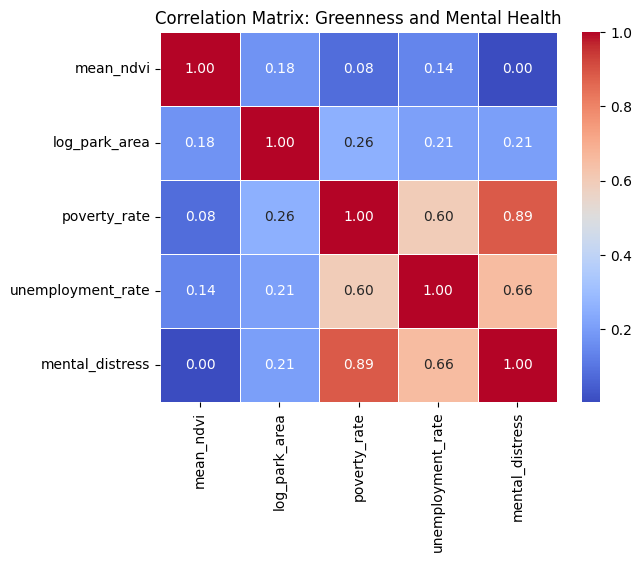

In [ ]:
cols = [
    "mean_ndvi",
    "log_park_area",
    "poverty_rate",
    "unemployment_rate",
    "mental_distress"
]
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix: Greenness and Mental Health")
plt.savefig(
    "figures/correlation_matrix.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Scatterplot

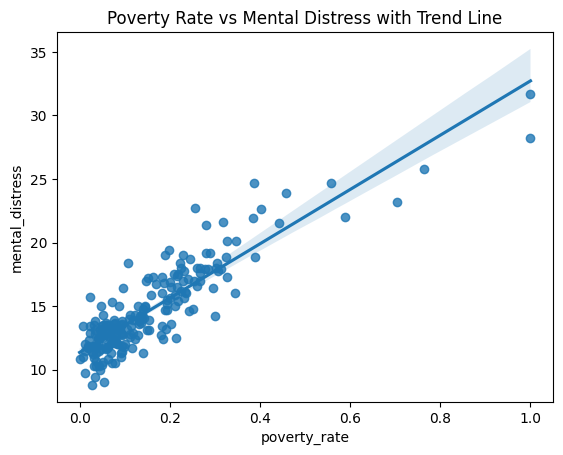

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(data=df, x="poverty_rate", y="mental_distress", scatter=True)
plt.title("Poverty Rate vs Mental Distress with Trend Line")

plt.savefig(
    "figures/poverty_rate_vs_mental_distress.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Poverty and Mental Distress:

Preliminary visualization suggests a strong positive relationship between poverty and mental distress across census tracts.

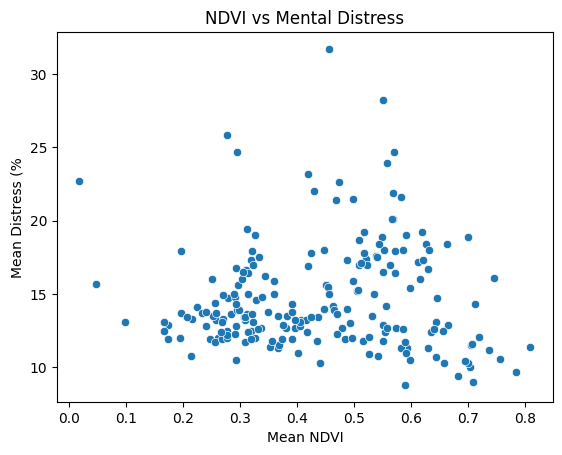

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='mean_ndvi', y="mental_distress")

plt.title("NDVI vs Mental Distress")
plt.xlabel("Mean NDVI")
plt.ylabel("Mean Distress (%")

plt.savefig(
    "figures/ndvi_vs_mental_distress.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

NDVI and Mental Distress:

Preliminary visualization suggests a negative positive relationship between NDVI and mental distress across census tracts.

<function matplotlib.pyplot.show(close=None, block=None)>

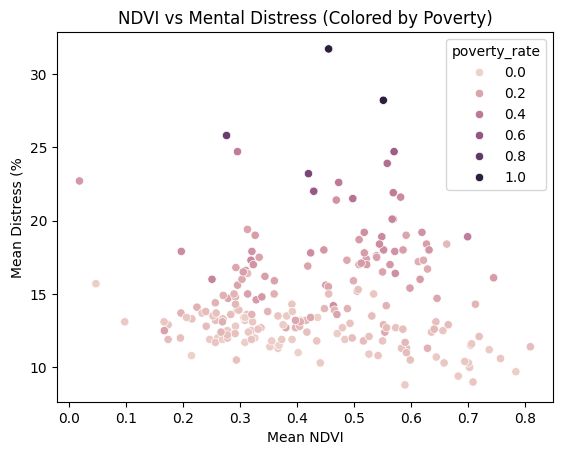

In [69]:
sns.scatterplot(data=df, x="mean_ndvi", y="mental_distress", hue="poverty_rate")
plt.title("NDVI vs Mental Distress (Colored by Poverty)")
plt.xlabel("Mean NDVI")
plt.ylabel("Mean Distress (%")
plt.show

## Modeling

In [70]:
#preparing model

df.isna().sum()
df = df.dropna()

y = df["mental_distress"]

#### Baseline Regression Model 
Question: Does greenness alone relate to mental distress?

In [71]:
# Model 1 - NDVI (only)

X1 = df[["mean_ndvi"]]
X1 = sm.add_constant(X1)

model1 = sm.OLS(y, X1).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:        mental_distress   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                  0.004948
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.944
Time:                        22:13:07   Log-Likelihood:                -554.60
No. Observations:                 206   AIC:                             1113.
Df Residuals:                     204   BIC:                             1120.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.6302      0.739     19.797      0.0

Obervations:

R-squared: 0.000
p.value: 0.944

There is no statistical relationship between NDVI and mental distress in this model. Greenness (NDVI) alone does not predict mental distress across DC tracts.

Questions: Do parks add explanatory power beyond NDVI?

In [72]:
# Model 2 - Adding Parks

X2 = df[["mean_ndvi", "log_park_area"]]
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:        mental_distress   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     4.649
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0106
Time:                        22:13:08   Log-Likelihood:                -549.99
No. Observations:                 206   AIC:                             1106.
Df Residuals:                     203   BIC:                             1116.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            14.6452      0.724     20.216

Observation:

R-squared: 0.044 
p-value: 0.003 

p-value is statstically signfiicant, more park area is associated with higher mental health distress

counter-intuative to my predication of more parks would lead to lower mental distress

other explanation? other cofounding issues, park location pattern issues, or a measurment issue 


Does greenness still matter after controlling for socioeconomic factors?

In [73]:
X3 = df[[
    "mean_ndvi",
    "log_park_area",
    "poverty_rate",
    "unemployment_rate"	
]]

X3 = sm.add_constant(X3)

model3 = sm.OLS(y, X3).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:        mental_distress   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     227.5
Date:                Thu, 07 May 2026   Prob (F-statistic):           2.02e-73
Time:                        22:13:08   Log-Likelihood:                -378.52
No. Observations:                 206   AIC:                             767.0
Df Residuals:                     201   BIC:                             783.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                11.9058      0.33

Observation:

poverty_income is our strongest predictor to mental distress
* A 0.1 (10 percentage point) increase in poverty → ~1.9 increase in mental distress

unemployment_income as expected answer the that Higher unemployment → higher mental distress

NDVI now has significane (p<.05). More greenness → lower mental distress, after controlling for SES

My overall conclusion is that Greenness does matter, but only when you account for socioeconomic context.

Before, NDVI effects were being masked by social inequalities but after being controlled we see the true enironmental effect 

In [74]:
print("Model 1 R²:", model1.rsquared)
print("Model 2 R²:", model2.rsquared)
print("Model 3 R²:", model3.rsquared)

Model 1 R²: 2.425490598523261e-05
Model 2 R²: 0.043799389240534725
Model 3 R²: 0.8190522817622297


## Sensitivity Analysis
Additional park exposure variables were evaluated to determine whether findings depended on how park exposure was operationalized.

In [75]:
X_ps = df[[
    "mean_ndvi",
    "park_share",
    "poverty_rate",
    "unemployment_rate"
]]

X_ps = sm.add_constant(X_ps)

model_ps = sm.OLS(y, X_ps).fit()

print(model_ps.summary())

                            OLS Regression Results                            
Dep. Variable:        mental_distress   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     227.2
Date:                Thu, 07 May 2026   Prob (F-statistic):           2.25e-73
Time:                        22:13:08   Log-Likelihood:                -378.63
No. Observations:                 206   AIC:                             767.3
Df Residuals:                     201   BIC:                             783.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                11.9197      0.32

In [76]:
X_hp = df[[
    "mean_ndvi",
    "has_park",
    "poverty_rate",
    "unemployment_rate"
]]

X_hp = sm.add_constant(X_hp)

model_hp = sm.OLS(y, X_hp).fit()

print(model_hp.summary())

                            OLS Regression Results                            
Dep. Variable:        mental_distress   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     228.1
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.59e-73
Time:                        22:13:08   Log-Likelihood:                -378.28
No. Observations:                 206   AIC:                             766.6
Df Residuals:                     201   BIC:                             783.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                12.0486      0.35

## Random Forest
#### Machine Learning Validation

A Random Forest Regressor was implemented to evaluate whether findings remained stable under a nonlinear predictive framework.

In [77]:
features = [
    "mean_ndvi",
    "log_park_area",
    "poverty_rate",
    "unemployment_rate"
]

X = df[features]
y = df["mental_distress"]

#Test and Train split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Train
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test) #predictions 

r2 = r2_score(y_test, y_pred)
mse= mean_squared_error(y_test,y_pred)
rmse= np.sqrt(mse)

print("Random Forest R²:", r2)
print("Random Forest RMSE:", rmse)

Random Forest R²: 0.8285098873760444
Random Forest RMSE: 1.5865584290562784


Obervations: 
RF outperformed the the OLS only slightly 
* showing relationships are mostly linear and well-captured already



Both linear regression and machine learning models produce consistent results, indicating that the relationship between socioeconomic factors, greenness, and mental distress is stable and not dependent on model choice.

Which variables matter the most for predicting mental distress?

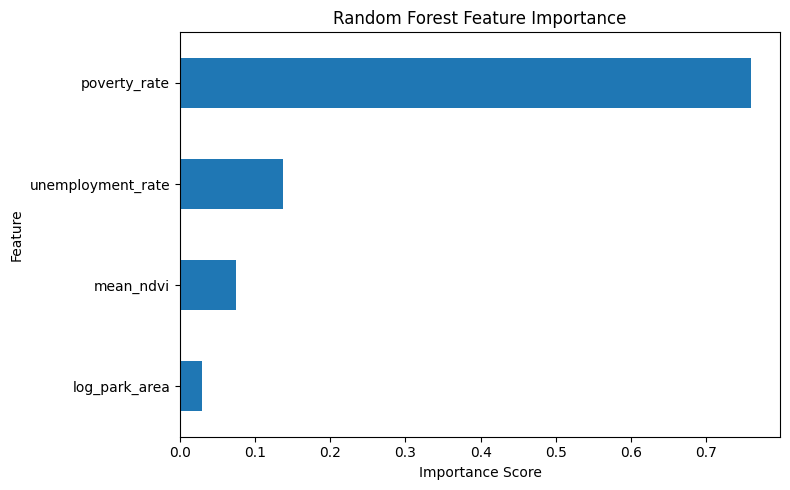

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix: Greenness and Mental Health")
plt.savefig(
    "figures/feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()